# ¡Hola Javier! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


--------

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>


¡Javier excelente trabajo completando este proyecto! Has demostrado habilidades destacables en el tratamiento de los datos, análisis exploratorio y visualización efectiva de información.

En el apartado de las pruebas de hipótesis aunque, de manera general, la implementación es correcta, para futuros análisis te recomiendo incluir una etapa previa con la prueba de Levene con el fin de verificar la igualdad de varianzas, lo cual contribuye a asegurar la validez estadística de los resultados.

En general, desarrollaste un muy buen análisis en este caso de estudio, sigue manteniendo esta combinación de habilidades técnicas, analíticas y estratégicas en tus futuros proyectos.

¡Te deseo muchos éxitos en tu próximo Sprint! 🚀

*Estado del Proyecto:* **Aprobado**


</div>

-------

# Sprint 6 - Proyecto

## Descripcción

El siguiente análisis utiliza un data frame con datos sobre ventas de videojuegos.

Descripción de datos
- Name (Nombre)

- Platform (Plataforma)

- Year_of_Release (Año de lanzamiento)

- Genre (Género) 

- NA_sales (ventas en Norteamérica en millones de dólares estadounidenses) 

- EU_sales (ventas en Europa en millones de dólares estadounidenses) 

- JP_sales (ventas en Japón en millones de dólares estadounidenses) 

- Other_sales (ventas en otros países en millones de dólares estadounidenses) 

- Critic_Score (máximo de 100) 

- User_Score (máximo de 10) 

- Rating (ESRB)

## 1. Preparación de los datos

## 1 Lectura del csv y llamada a librerías

In [1]:
# Llamadas a librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
# Lectura del archivo csv
df = pd.read_csv('/datasets/games.csv')

In [3]:
# Visión general del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Cambio los nombres de columns a minúscula
df.columns = df.columns.str.lower()

# Verifico el cambio
df.columns

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo importando las librerías y los datos del proyecto. Adicionalmente usaste correctamente la función `info`, esto te permite hacer una primera revisión de los datos, su estructura y contenido. 

Además una excelente práctica convertir los nombres de las columnas a minúsculas para facilitar el trabajo posterior y evitar errores por tener una combinación de mayúsculas y minúsculas.

</div>

## 2 Preparación de los datos

- Tratamiento de valores ausentes y conversión de tipos

In [6]:
# Compruebo valores ausentes para cada columna
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [7]:
# Compruebo el tipo de dato de cada columna
df.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

## Columna `name`:
- Hay dos filas con valores ausentes, voy a sustitur por el valor str 'sin_nombre'.

In [8]:
# Cambio los 2 valores por sin nombre
df['name'].fillna('sin_nombre', inplace = True)

## Columna `platform`:
- Cambio los nombres de las plataformas a mayúsculas

In [9]:
df['platform'] = df['platform'].str.upper()
df['platform'].unique()

array(['WII', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XONE',
       'WIIU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

## Columna `year_of_release` 
- Se tratan los valores ausentes y se cambia a tipo int, especificación de métodos en comentarios del código.

In [10]:
# Se ordena el df por name
df = df.sort_values(by = 'platform').reset_index()
# Se elimina el índice convertido a columna con .reset_index()
df = df.drop(columns = 'index')
"""
Ahora que he ordenado por name se puede usar bfill y ffill
se puede rellenar los valores del año por adyacencia de platform
con bastante precisión
"""
df['year_of_release'].bfill(inplace=True) # Rellenar con valor anterior
df['year_of_release'].ffill(inplace=True) # Rellenar con valor siguiente
df['year_of_release'].isna().sum()

0

In [11]:
# Se cambia el tipo de dato de float a int
df['year_of_release'] = df['year_of_release'].astype(int)

Durante el añalis y creación de graficas he detectado esta anomalia en una fila de 'year_of_release'

In [12]:
# Hay un valor incorrecto para el año de lanzamiento aquí
df.query('platform == "DS" and year_of_release == 1985')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1169,Strongest Tokyo University Shogi DS,DS,1985,Action,0.0,0.0,0.02,0.0,NaN,NaN,NaN


In [13]:
# Cambio el año del lanzamiento del juego Strongest Tokyo University Shogi DS
df.loc[1169, 'year_of_release'] = 2004
df.query('name == "Strongest Tokyo University Shogi DS"')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1169,Strongest Tokyo University Shogi DS,DS,2004,Action,0.0,0.0,0.02,0.0,NaN,NaN,NaN




## Columnas `*_sales`
- Reviso el tipo de dato, puesto que no hay valores ausentes



In [14]:
# Visualizo valores unicos para ver como son
df['na_sales'].unique()

array([7.000e-02, 2.600e-01, 3.700e-01, 2.500e-01, 7.400e-01, 7.280e+00,
       2.400e-01, 7.600e-01, 3.800e-01, 5.800e-01, 2.300e-01, 8.100e-01,
       4.210e+00, 2.200e-01, 4.000e+00, 2.100e-01, 4.000e-01, 7.300e-01,
       7.200e-01, 3.200e-01, 6.500e-01, 3.100e-01, 3.000e-01, 6.300e-01,
       3.300e-01, 6.700e-01, 6.200e-01, 2.900e-01, 3.500e-01, 6.800e-01,
       2.800e-01, 2.700e-01, 6.000e-01, 3.600e-01, 8.700e-01, 4.200e-01,
       1.400e-01, 4.600e-01, 1.170e+00, 1.180e+00, 1.210e+00, 1.220e+00,
       1.300e-01, 4.700e-01, 1.260e+00, 1.360e+00, 4.800e-01, 1.200e-01,
       1.480e+00, 1.490e+00, 1.520e+00, 1.540e+00, 5.000e-01, 1.840e+00,
       1.990e+00, 2.060e+00, 5.200e-01, 2.360e+00, 2.560e+00, 5.500e-01,
       1.100e+00, 2.000e-01, 9.000e-01, 4.300e-01, 9.100e-01, 1.800e-01,
       9.900e-01, 4.100e-01, 4.400e-01, 4.500e-01, 1.010e+00, 1.030e+00,
       1.050e+00, 1.070e+00, 1.500e-01, 0.000e+00, 9.000e-02, 6.000e-02,
       1.900e-01, 4.000e-02, 8.000e-02, 1.000e-01, 

Curioso, valores con notación científica, se quedan tal y como están.



## Columna `genre`
- Se cambia el valor str de la columna genre a 'indeterminado' cuando el valor es ausente



In [15]:
# Sustituyo los dos ausentes por indeterminado
df['genre'] = df['genre'].fillna('indeterminado')

In [16]:
# Visualizo para ver los valores unicos en la columna de críticas
df['genre'].unique()

array(['Sports', 'Racing', 'Action', 'Misc', 'Puzzle', 'Adventure',
       'Shooter', 'Platform', 'Fighting', 'Simulation', 'Role-Playing',
       'Strategy', 'indeterminado'], dtype=object)

## Columna `critic_score`
- El tipo de dato float de `critic_score` puede ser cambiado de `float` a  `int`


In [17]:
# Cambio a Int64 que acepta valores ausentes en la columna
df['critic_score'] = df['critic_score'].astype('Int64')

El tipo de dato float de critic_score es `object` puede ser cambiado a int

In [18]:
# Fuerzo la conversión a numérico
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
# Compruebo el cambio
df['user_score'].dtypes

dtype('float64')

## Columna `rating`
- Hay muchos valores ausentes en rating, voy a dejarlos tal cual, en las siguientes celdas especifico porqué.

In [19]:
print('Hay',df['rating'].isna().sum(),'valores ausentes en rating')

Hay 6766 valores ausentes en rating


In [20]:
# Visualizo los casos únicos
df['rating'].unique()

array([nan, 'E10+', 'M', 'E', 'T', 'EC', 'RP', 'K-A', 'AO'], dtype=object)

Dejo los valores ausentes como están, suponen la mitad de las muestras, si los elimino afectaría al análisis de las ventas.

## Comprobación de filas duplicadas

In [21]:
# Compruebo filas duplicadas
df.duplicated().sum()

0

No hay filas duplicadas

In [22]:
# Vista del df general despues de los cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   Int64  
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), int64(1), object(4)
memory usage: 1.4+ MB


## Resumen tratamiento de valores ausentes y conversión de tipos

- Había 2 valores ausentes en name, los he renombrado a 'sin_nombre'.
- Para la columna `year_of_release` he decidido cambiar el tipo de dato a int, he ordenado el df por `platform` ajustando mejor la estimación de fecha de lanzamiento con la asignación de valores adyacentes concatenando bbfill y ffill.
- Las columnas para ventas tienen el formato adecuado, en una inspeccion he descubierto que se guardan en forma de notación científica, no hay valores ausentes y no se hacen cambios.
- `critic_score` : he cambiado los valores no ausentes a Int64, se mantienen los valores ausentes
- `user_score` : el tipo de dato era object he cambiado los valores no ausentes a float64, se mantienen los valores ausentes
- `rating` : no hay cambio de tipo de dato, se mantienen los valores ausentes, para no deformar el analisis de ventas.

- He decidido mantener los valores de las columnas donde había muchos casos de valores ausentes, esto me facilitará más adelante filtrar y crear df alternativos donde tenga que analizar los valores de puntuaciones, si los eliminará afectaría el analisis de las ventas.
- Las razones por las que hay datos ausentes puede se variada, lo más seguro es que sean datos previos a la adopción de internet, la obtención de datos para fechas anteriores a internet es un un proceso 100% manual, consultando registros de empresa sin digitalizar, revistas, periódicos etc. Es por todo eso que quiza esos valores no han sido obtenidos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Con respecto al manejo de datos faltantes, las estrategias que planteas son válidas para el contexto del caso de estudio; no obstante, acá te comparto un artículo donde hablan sobre diferentes [métodos de manejo de datos faltanes](https://www.kaggle.com/code/parulpandey/a-guide-to-handling-missing-values-in-python) que seguro te serán útiles en futuros proyectos.

</div>

## 3. Análisis de datos

## ¿Cuántos juegos fueron lanzados en diferentes años?

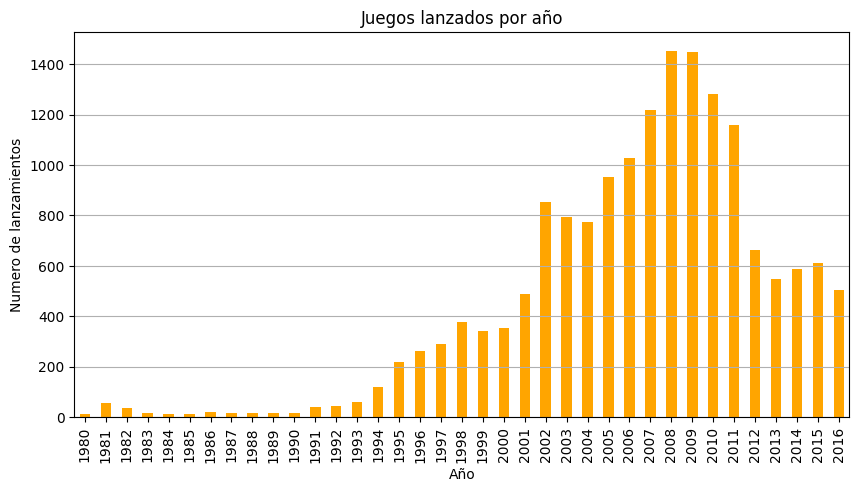

In [23]:
# Agrupo por año y numero de lanzamientos
juegos_por_año = df.groupby("year_of_release")["name"].count() 
juegos_por_año.plot(
    kind="bar",
    figsize=(10,5),
    color="orange",
    title="Juegos lanzados por año"
)
plt.xlabel('Año')
plt.ylabel('Numero de lanzamientos')
plt.grid(True, axis='y')
plt.show()

Se puede ver la progresión de numero de lanzamientos en la historia de los videojuegos, el boom de lanzamientos comenzó en la década de los 90.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Muy buen trabajo! La gráfica muestra un crecimiento hasta 2008-2009, seguido de una caída en lanzamientos. Esto podría deberse al éxito de consolas como PS3 y Xbox 360, y luego a cambios en la industria: más enfoque en calidad, auge de juegos móviles, distribución digital o la crisis de 2008.

</div>

## ¿Cómo varían las ventas de una plataforma a otra?

In [24]:
# Creo una columna con las ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

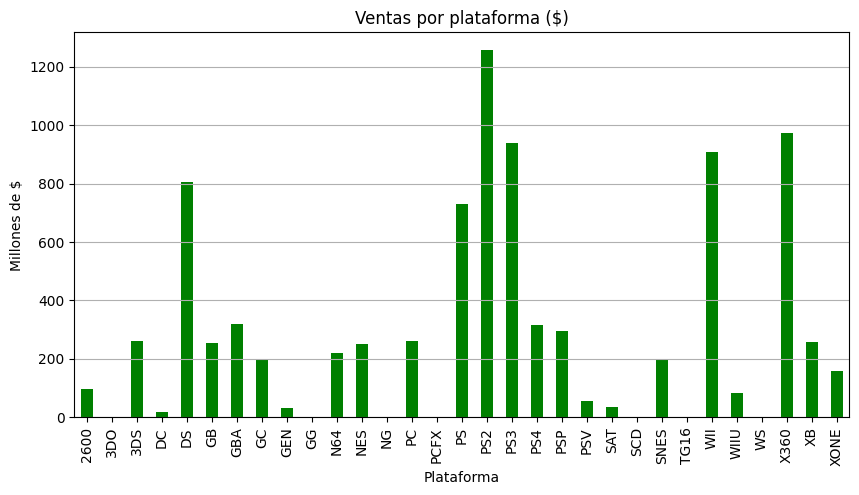

In [25]:
# Agrupo por plataforma y ventas totales
ventas_plataformas = df.groupby("platform")["total_sales"].sum()
ventas_plataformas.plot(
    kind="bar",
    figsize=(10,5),
    color="green",
    title="Ventas por plataforma ($)"
)
plt.xlabel('Plataforma')
plt.ylabel('Millones de $')
plt.grid(True, axis='y')
plt.show()

Por orden de mayor a menor las plataformas con más volumen de ventas total:
- PS2
- X360
- PS3
- Wii
- DS
- PS

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Perfecto! La gráfica muestra que la PlayStation 2 lidera en ventas, seguida por la Xbox 360 y la PlayStation 3. También destacan la Wii, Nintendo DS y la primera PlayStation. Las consolas más antiguas o menos populares tienen ventas mucho menores, lo que refleja la preferencia del mercado por Sony y Microsoft.

</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

En este tipo de gráficas, donde el eje X no tiene un orden natural es mejor ordenarla por tamaño de barra, de esta forma el análisis es más directo

</div>

## Plataformas TOP 5 según las ventas totales por año

In [26]:
# Ordeno para ver las 5 plataformas con más ventas
ventas_plataformas = ventas_plataformas.sort_values(ascending=False)
ventas_plataformas.head(5)

platform
PS2     1255.77
X360     971.42
PS3      939.65
WII      907.51
DS       806.12
Name: total_sales, dtype: float64

In [27]:
# Obtengo la lista de las plataformas con más ventas 
top_plataformas = ventas_plataformas.head(5).index
# Creo una máscara bool para filtrar top_plataformas
mask_top_plataformas = df['platform'].isin(top_plataformas)
# Aplico la máscara
df_top_plataformas = df[mask_top_plataformas].copy()

In [28]:
# Agrupar por año y plataforma
año_plataforma_ventas_top = df_top_plataformas.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

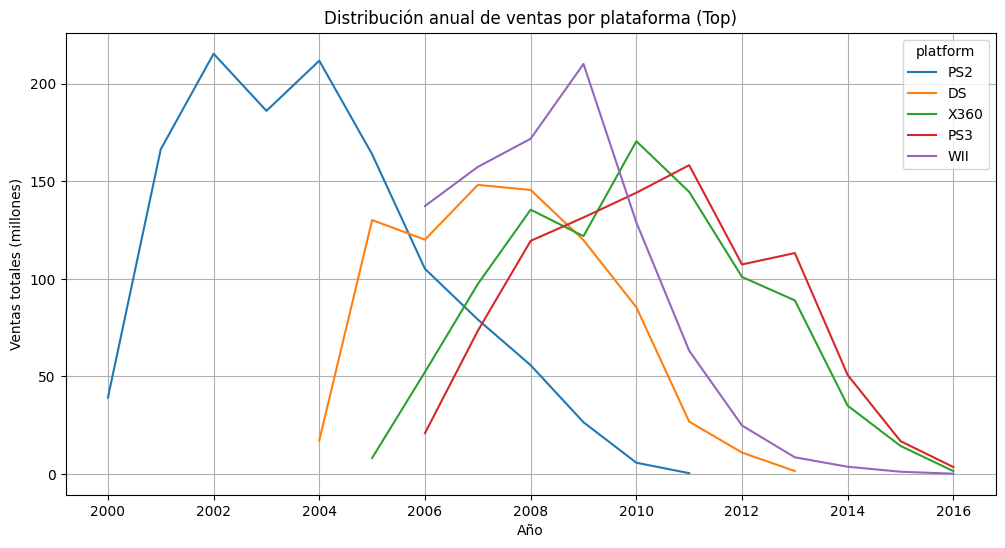

In [29]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data = año_plataforma_ventas_top,
    x='year_of_release',
    y='total_sales',
    hue='platform'
)

plt.title('Distribución anual de ventas por plataforma (Top)')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones)')
plt.grid(True)
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

El gráfico confirma que cada generación de consolas tiene un ciclo de vida con un período de auge y una posterior caída, lo que sugiere que el éxito de un videojuego está fuertemente vinculado al momento en el que es lanzado dentro de ese ciclo. Buen trabajo

</div>

## Plataformas clásicas según las ventas totales por año

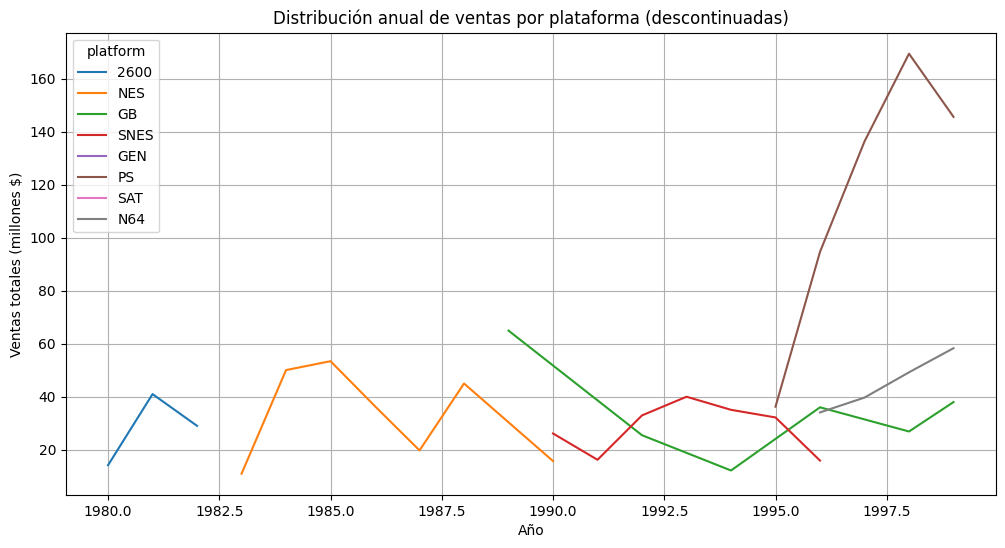

In [30]:
## Lista de las plataformas descontinuadas_populares
descontinuadas_populares = df[df['year_of_release'] < 2000].copy()
descontinuadas_populares = descontinuadas_populares.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
descontinuadas_populares = descontinuadas_populares[descontinuadas_populares['total_sales'] > 10]
# PC sigue en mercado, lo descarto
descontinuadas_populares = descontinuadas_populares[descontinuadas_populares['platform'] != 'PC']

plt.figure(figsize=(12,6))
sns.lineplot(
    data = descontinuadas_populares,
    x='year_of_release',
    y='total_sales',
    hue='platform'
)

plt.title('Distribución anual de ventas por plataforma (descontinuadas)')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones $)')
plt.grid(True)
plt.show()


Se puede observar el recorrido de ventas anuales de plataformas clásicas (previas al año 2000), con ventas anuales superiores a 10 millones a traves de los años.

## ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [31]:
# Agrupo por plataforma y año de primer y ultimo lanzamiento
primer_lanzamiento = df.groupby('platform')['year_of_release'].min().reset_index()
ultimo_lanzamiento = df.groupby('platform')['year_of_release'].max().reset_index()
# Renombro las columnas, si no mantendrían el nombre 'year_of_release'
primer_lanzamiento.rename(columns={'year_of_release': 'año_primer_lanzamiento'}, inplace = True)
ultimo_lanzamiento.rename(columns={'year_of_release': 'año_ultimo_lanzamiento'}, inplace = True)
# Uno los dos
plataforma_años = primer_lanzamiento.merge(ultimo_lanzamiento, on="platform", how="inner")
plataforma_años

,platform,año_primer_lanzamiento,año_ultimo_lanzamiento
0,2600,1980,1989
1,3DO,1994,1995
2,3DS,2011,2016
3,DC,1998,2008
4,DS,2004,2013
5,GB,1988,2001
6,GBA,2000,2007
7,GC,2001,2007
8,GEN,1990,1994
9,GG,1992,1992


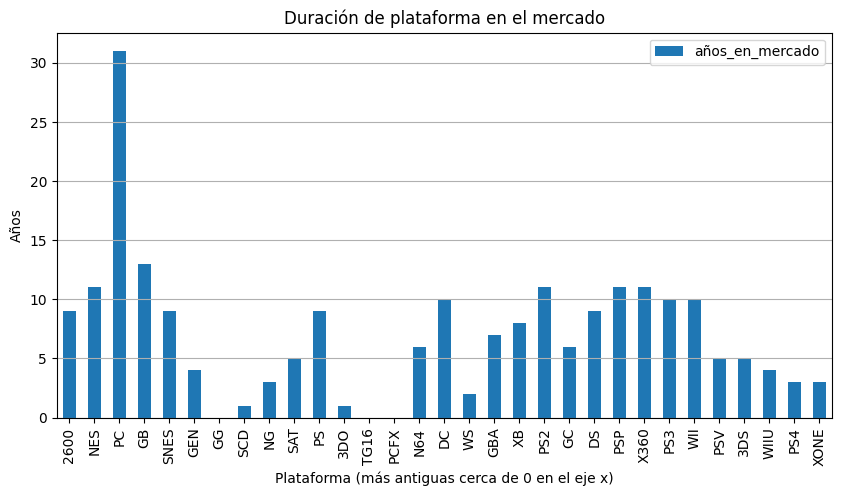

In [32]:
# Obtengo el tiempo en el mercado de la plataforma
plataforma_años['años_en_mercado'] = plataforma_años['año_ultimo_lanzamiento'] - plataforma_años['año_primer_lanzamiento']
plataforma_años = plataforma_años.sort_values(by = 'año_primer_lanzamiento')
plataforma_años.plot(
    title= 'Duración de plataforma en el mercado',
    x = 'platform',
    y = 'años_en_mercado',
    kind="bar",
    figsize=(10,5),
)
plt.xlabel('Plataforma (más antiguas cerca de 0 en el eje x)')
plt.ylabel('Años')
plt.grid(axis = 'y')
plt.show()


Salvo el caso de PC, los años de vida en el mercado de las plataformas está entre 5 y 10 años, las plataformas modernas en el momento de recogida de los datos (2016) es de suponer que tendrán más recorrido (PSV,3DS,WIIU,PS4,XONE)

## Duración en mercado de plataformas contemporáneas (2000-2010)

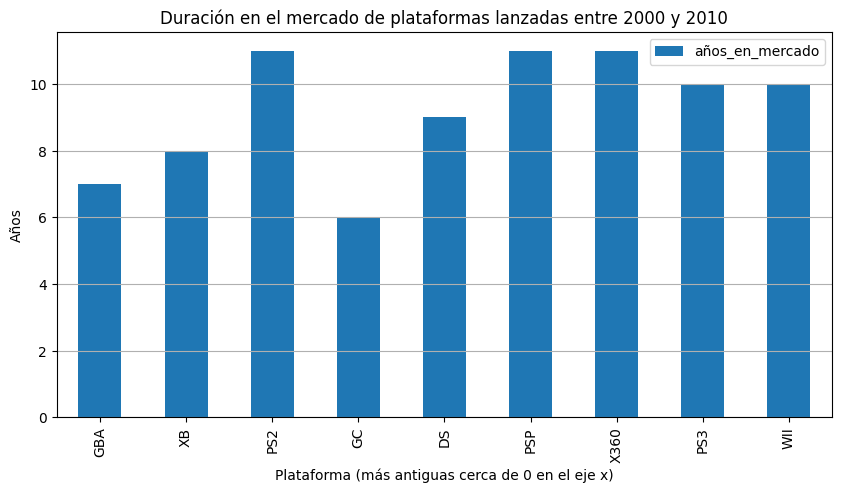

In [33]:
# Alternativa para el peridodo a partir del año 2000
plataformas_comtemporaneas = plataforma_años.query("año_primer_lanzamiento >= 2000 and año_primer_lanzamiento <= 2010").sort_values(by = 'año_primer_lanzamiento')
plataformas_comtemporaneas.plot(
    title= 'Duración en el mercado de plataformas lanzadas entre 2000 y 2010',
    x = 'platform',
    y = 'años_en_mercado',
    kind="bar",
    figsize=(10,5),
)
plt.xlabel('Plataforma (más antiguas cerca de 0 en el eje x)')
plt.ylabel('Años')
plt.grid(axis = 'y')
plt.show()

In [34]:
print('...Consolas lanzadas entre 2000 y 2010...')
print('Media de la duración en mercado: ',round(plataformas_comtemporaneas['años_en_mercado'].mean(),2), 'años')

...Consolas lanzadas entre 2000 y 2010...
Media de la duración en mercado:  9.22 años


La vida media de de las plataformas contemporáneas es bastante pareja, es posible que haya ciertas convenciones entre competidores (por ejemplo : mismas tecnologías).

## Diagrama de caja para las ventas globales de todos los juegos

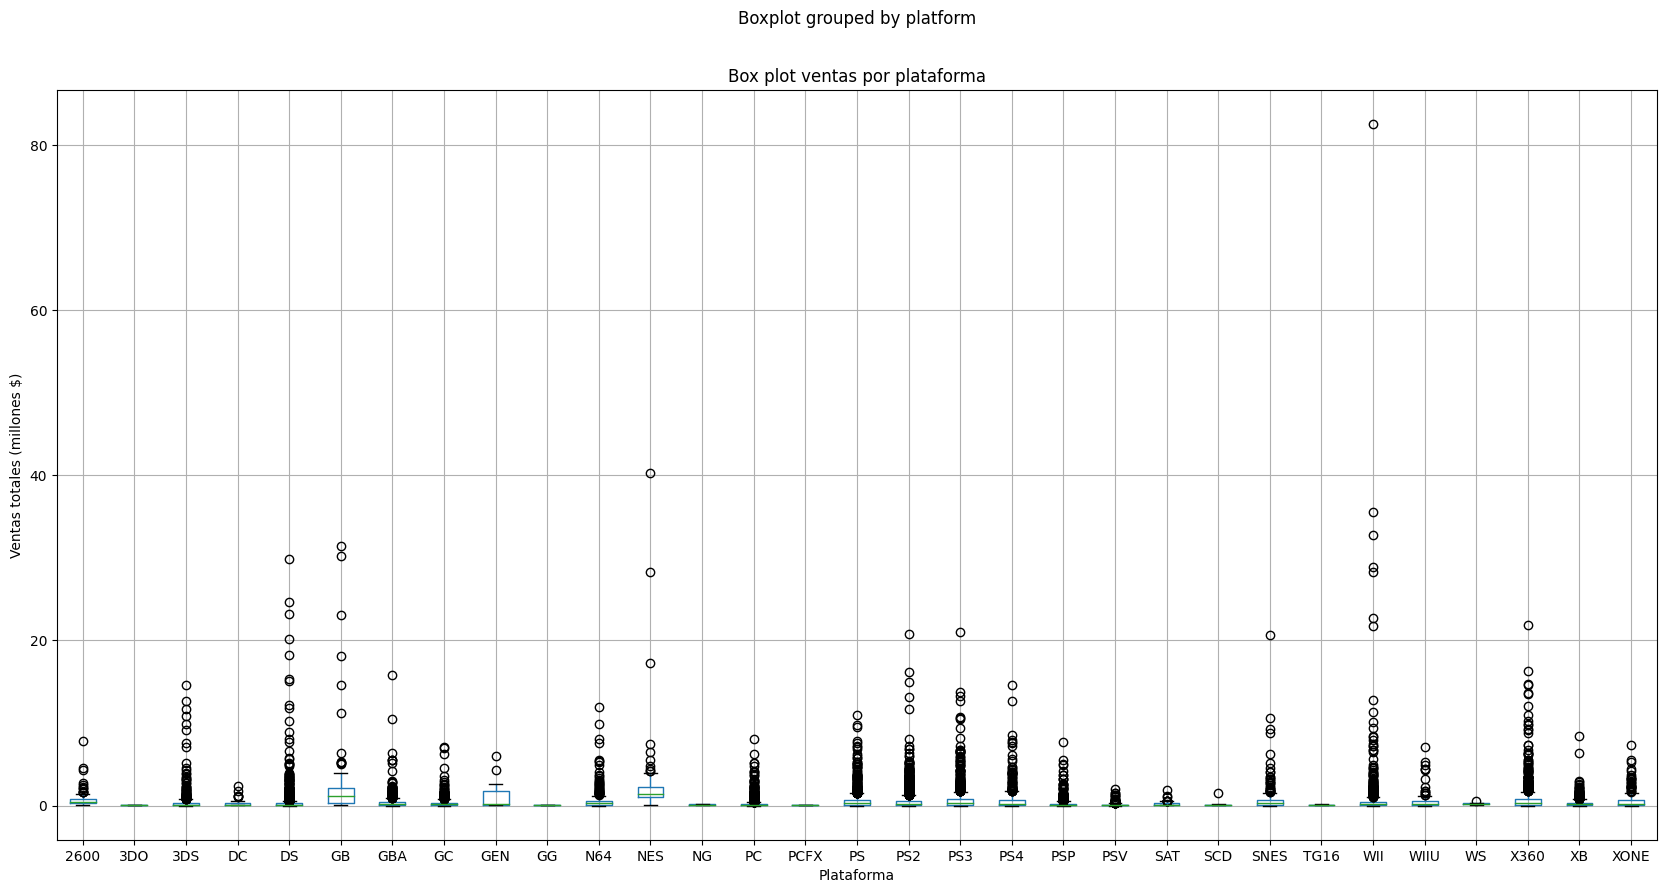

In [35]:
# Utilizo el data frame original con la columna total_sales
df.sort_values(by = 'year_of_release').boxplot(column="total_sales",
                                               by="platform",
                                               figsize=(20,10),
                                               grid=True)
plt.title('Box plot ventas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones $)')
plt.show()

Al haber "superventas" la representación de las cajas no es muy legible, voy a obviar los valores atípicos de estos para centrarme en los promedio.

In [36]:
df.query('platform == "Wii" and total_sales > 80')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales


Wii Sports el top de superventas

In [37]:
df.query('platform == "NES" and total_sales > 40')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
4760,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,NaN,40.24


El superventas por excelencia Super Mario

## Diagrama de caja para las ventas globales de todos los juegos (ajustado para ver cajas)

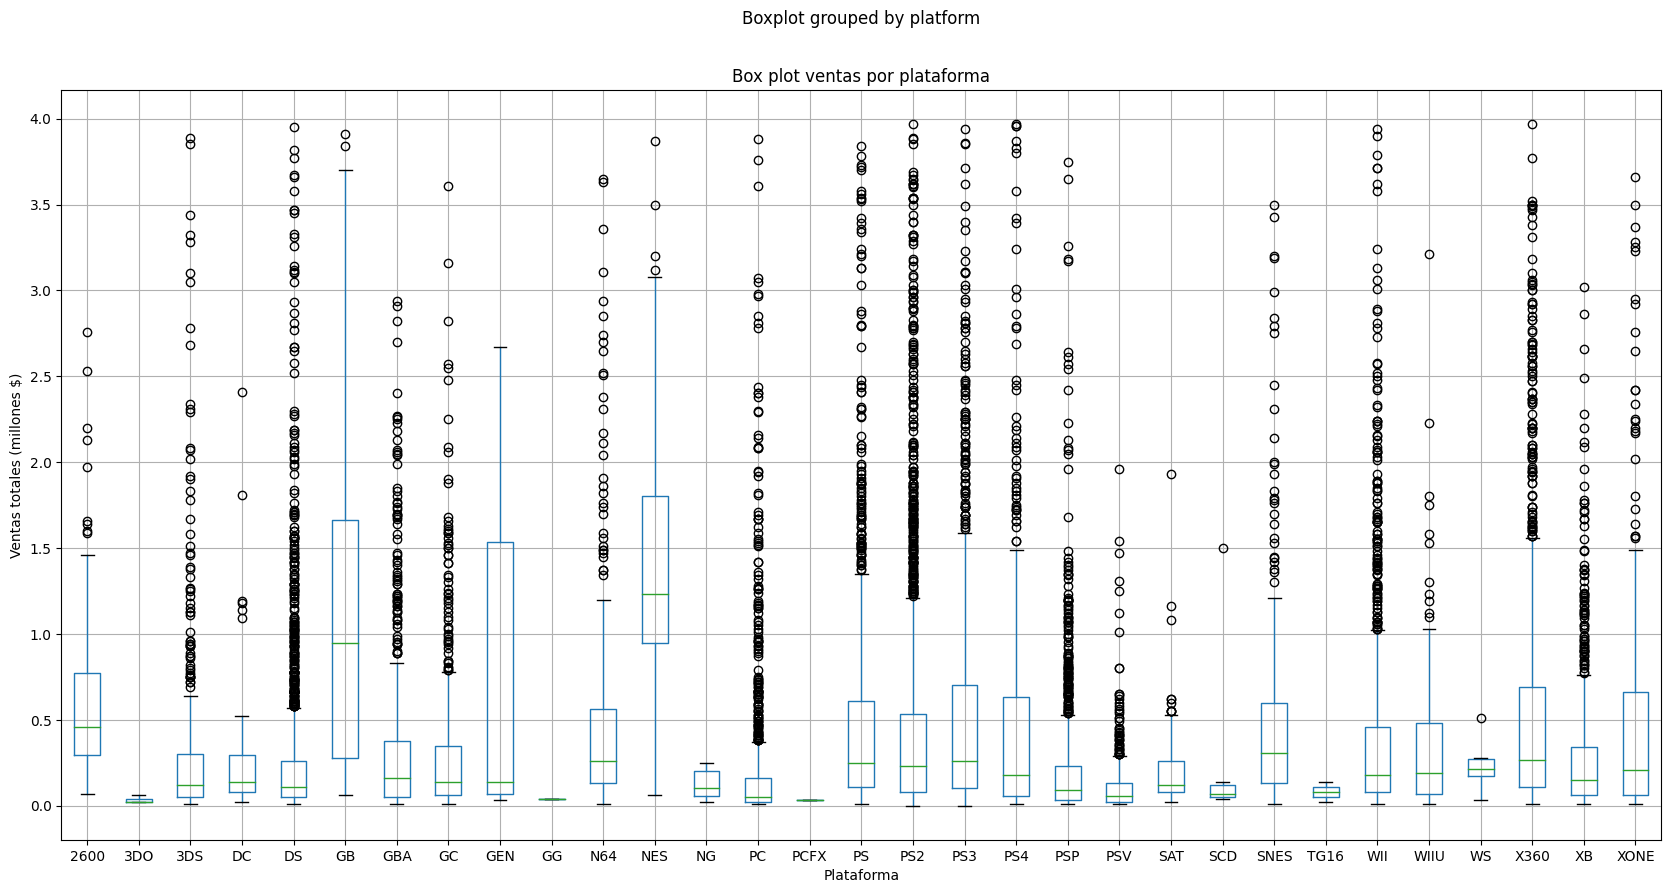

In [38]:
# Voy ajustando el valor de filtrado para total sales hasta que se ven bien las cajas
df[df['total_sales'] < 4].sort_values(by = 'year_of_release').boxplot(column="total_sales",
                                                                      by="platform",
                                                                      figsize=(20,10),
                                                                      grid=True)
plt.title('Box plot ventas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones $)')
plt.show()

- Las cajas se encuentran entre casi 0 y 2 millones de euros.
- La plataforma Game Boy tiene una distribución con una cola de gato larga para valores superiores, (obviando valores atípicos) los valores de la caja representan que los ingresos por titúlo se mueven entre (Bigote inferior) 0.1 y (Bigote superior) 3.7 millones de $, por el tamaño de los cuartiles se observa que los valores de venta por titúlo entre los cuartiles Q1 Y Q4 están entre Q1(cuartil inferior) 0.25 y Q4(cuartil superior) 1.6 millones de dolares, quiere decir que la mayoria de ventas están en ese rango.

Descripción general:
- Prevalencia de bigotes superiores más largos que el inferior y valores atípicos superiores.
- Según la forma de la distribución: asimetrica a la derecha, cola larga.
- Hay titulos que venden muchísimo y otros que no (los que se encuentran en la mediana de los cuartiles)

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo obteniendo los *box-plot*. Estos muestran que la mayoría de los juegos tienen ventas bajas, hay valores extremos que dominan en cada plataforma. Esto muestra que el éxito de un juego no depende solo de la consola, sino también de su popularidad y estrategia de marketing.

</div>

## Correlación entre ventas totales y critic_score

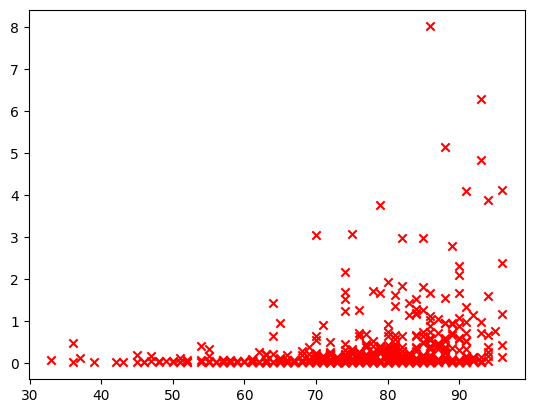

<Figure size 2000x2000 with 0 Axes>

Tabla de correlación
              critic_score  total_sales
critic_score      1.000000     0.256887
total_sales       0.256887     1.000000


In [39]:
df_PC = df[df['platform'] == "PC"]
df_PC_dropna = df_PC.dropna()
plt.scatter(df_PC_dropna['critic_score'], df_PC_dropna['total_sales'], marker='x', color='red')
plt.figure(figsize=(20, 20))
plt.show()
correlacion_critica_ventas = df_PC[['critic_score', 'total_sales']].corr(method='pearson')
print('Tabla de correlación')
print(correlacion_critica_ventas)

Ligera correlación positiva para valores de critic_score cuando es mayor que 60

## Correlación entre ventas totales y user_score

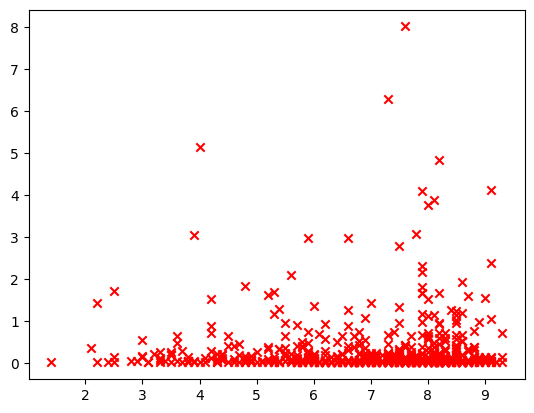

<Figure size 2000x2000 with 0 Axes>

Tabla de correlación
             user_score  total_sales
user_score     1.000000     0.010476
total_sales    0.010476     1.000000


In [40]:
plt.scatter(df_PC_dropna['user_score'], df_PC_dropna['total_sales'], marker='x', color='red')
plt.figure(figsize=(20, 20))
plt.show()
correlacion_user_score_ventas = df_PC[['user_score', 'total_sales']].corr(method='pearson')
print('Tabla de correlación')
print(correlacion_user_score_ventas)

Muy ligera correlación positiva para valores de user_score cuando es mayor que 4, por el valor de la correlación tan cercano a `0` se puede estimar que las críticas de los usuarios no están relacionadas con las ventas. Aunque hay valores que destacan, los valores de ventas se concentran en el mismo punto.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Genial, Con esta información se evidencia que la puntuación de los críticos está un poco más relacionada con las ventas que la de los usuarios, aunque la correlación es débil. En *User_Score* no hay una tendencia clara, pero en *Critic_Score*, los juegos mejor calificados tienden a vender más. Esto sugiere que las críticas especializadas pueden tener mayor impacto en las ventas.

</div>

## Comparación de ventas de los mismos juegos de PC en otras plataformas (multiplataformas)

In [41]:
# Compruebo las ventas totales de PC
df_PC['total_sales'].sum()

259.52

In [42]:
# Creo una lista con los juegos de PC
lista_juegos_PC = df_PC['name'].unique()
# creo un df con juegos que no son de PC
df_no_PC = df[df['platform'] != 'PC']
# Creo un dataframe con coincidencias par ala lista de juegos PC
# Se podrían considerar multiplataformas
df_no_PC = df_no_PC[df_no_PC['name'].isin(lista_juegos_PC)]

In [43]:
# Concateno los dos df
# "Unión vertical"
multiplataformas_PC = pd.concat([df_no_PC, df_PC], ignore_index=True)
multiplataformas_PC

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Rayman Origins,3DS,2012,Platform,0.06,0.08,0.00,0.01,71,6.3,E10+,0.15
1,F1 2011,3DS,2011,Racing,0.07,0.08,0.00,0.02,59,6.8,E,0.17
2,LEGO Star Wars III: The Clone Wars,3DS,2011,Action,0.61,0.43,0.00,0.09,67,6.1,E10+,1.13
3,Terraria,3DS,2016,Action,0.00,0.04,0.05,0.00,71,7.1,T,0.09
4,Skylanders: Spyro's Adventure,3DS,2011,Action,0.32,0.20,0.00,0.05,82,4.9,E10+,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...
2362,Star Wars The Clone Wars: Republic Heroes,PC,2009,Action,0.00,0.02,0.00,0.00,46,4.7,T,0.02
2363,F1 Race Stars,PC,2012,Racing,0.00,0.02,0.00,0.00,62,5.4,E,0.02
2364,Edna & Harvey: Harvey's New Eyes,PC,2011,Adventure,0.00,0.07,0.00,0.01,<NA>,NaN,NaN,0.08
2365,Ghost Pirates of Vooju Island,PC,2009,Adventure,0.00,0.02,0.00,0.00,66,NaN,T,0.02


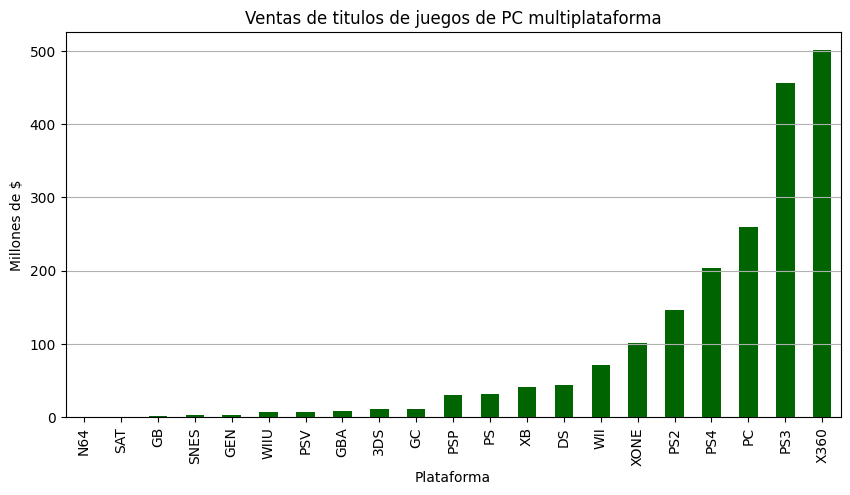

In [44]:
# Agrupo por plataforma y ventas totales, ordeno los valores de ventas totales.
plot_multi = multiplataformas_PC.groupby("platform")["total_sales"].sum().sort_values(ascending = True) 
plot_multi.plot(
    kind="bar",
    figsize=(10,5),
    color="darkgreen",
    title="Ventas de titulos de juegos de PC multiplataforma"
)
plt.xlabel('Plataforma')
plt.ylabel('Millones de $')
plt.grid(True, axis='y')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo analizando los juegos multiplataformas, con esta información es posible relacionar los juegos con mayor popularidad y las plataformas más comercializadas. 

</div>

## Comparación de ventas por genero

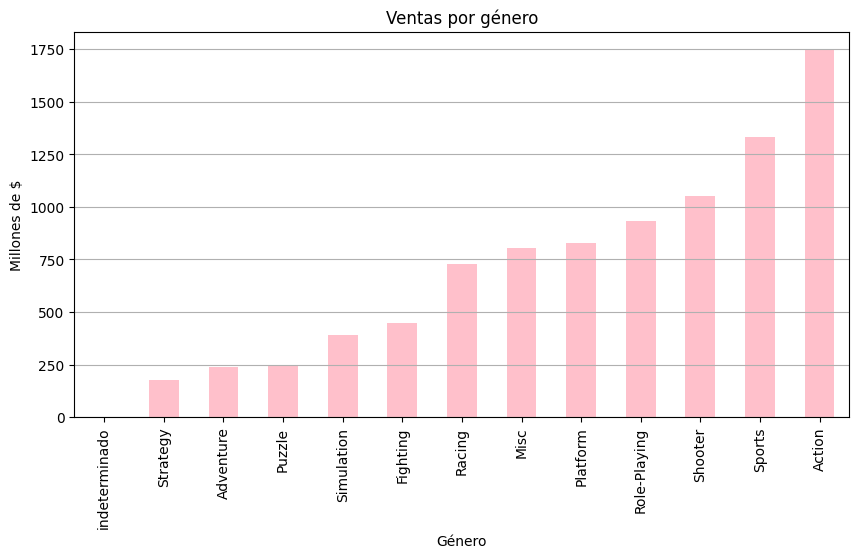

In [45]:
# Agrupo por género y ventas totales, ordeno los valores de ventas totales.
genero_sales = df.groupby("genre")["total_sales"].sum().sort_values(ascending = True) 
genero_sales.plot(
    kind="bar",
    figsize=(10,5),
    color="pink",
    title="Ventas por género"
)
plt.xlabel('Género')
plt.ylabel('Millones de $')
plt.grid(True, axis='y')
plt.show()

- El podio de ventas por géneros es para Action, Sports y Shooter.
- Destacan los géneros de rol, plataforma, miscelaneo y conducción.
- Los juegos de lucha tuvieron su momento, ahora están relegados a posiciones de ventas totales inferiores.
- Parece que los géneros que se presuponen más "intelectuales" o de narrativas personalizadas son menos populares.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Excelente trabajo! En efecto se observa que los juegos de acción y deportes lideran en ventas. Los géneros de rol y shooter también destacan, aunque en menor medida. En cambio, los de estrategia, aventura y puzzle muestran ventas más bajas, lo que indica una demanda más limitada.

</div>

## 4. Crea un perfil de usuario para cada región

Para cada región (NA, UE, JP) determina:

- Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.
- Los cinco géneros principales. Explica la diferencia.
- Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

## Perfil de ventas de plataformas populares por región.

In [46]:
# Creo una función para obtener las 5 plataformas con más ventas por región
def top_platforms_region(df, sales_region):
    resultado = df
    resultado = resultado.groupby('platform')[sales_region].sum()
    resultado = resultado.sort_values(ascending = False)
    resultado = resultado.head(5).reset_index()
    return resultado

In [47]:
# Aplico la función y creo data frame parciales
top_NA_platforms = top_platforms_region(df,'na_sales')
top_EU_platforms = top_platforms_region(df,'eu_sales')
top_JP_platforms = top_platforms_region(df,'jp_sales')

In [48]:
# Creo un data frame que contiene las ventas por plataformas combinadas
comparacion_plataformas_regiones = pd.DataFrame({
    "NA": top_NA_platforms.set_index("platform")["na_sales"],
    "EU": top_EU_platforms.set_index("platform")["eu_sales"],
    "JP": top_JP_platforms.set_index("platform")["jp_sales"]
})
comparacion_plataformas_regiones

,NA,EU,JP
platform,,,
3DS,NaN,NaN,100.67
DS,382.40,NaN,175.57
PS,NaN,213.61,139.82
PS2,583.84,339.29,139.20
PS3,393.49,330.29,NaN
SNES,NaN,NaN,116.55
WII,496.90,262.21,NaN
X360,602.47,270.76,NaN


Al unir los datos se observa que hay valores nulos, en las celdas que sigue lo soluciono.

In [49]:
# Obtengo una lista con las plataformas populares en todas las regiones
lista_platform = comparacion_plataformas_regiones.index
# Creo una lista con el nombre de las columnas en las que se hacen los cálculos
lista_region_sales = ['na_sales','jp_sales','eu_sales']
# Obtengo un df que contiene los juegos populares
df_top_platforms_region = df[df['platform'].isin(lista_platform)]
# Agrupo por plataforma y ventas por regiones
df_top_platforms_region = df_top_platforms_region.groupby('platform')[lista_region_sales].sum()
df_top_platforms_region

,na_sales,jp_sales,eu_sales
platform,,,
3DS,83.49,100.67,61.48
DS,382.40,175.57,188.89
PS,336.52,139.82,213.61
PS2,583.84,139.20,339.29
PS3,393.49,80.19,330.29
SNES,61.23,116.55,19.04
WII,496.90,69.33,262.21
X360,602.47,12.43,270.76


Agrupación sin valores ausentes.

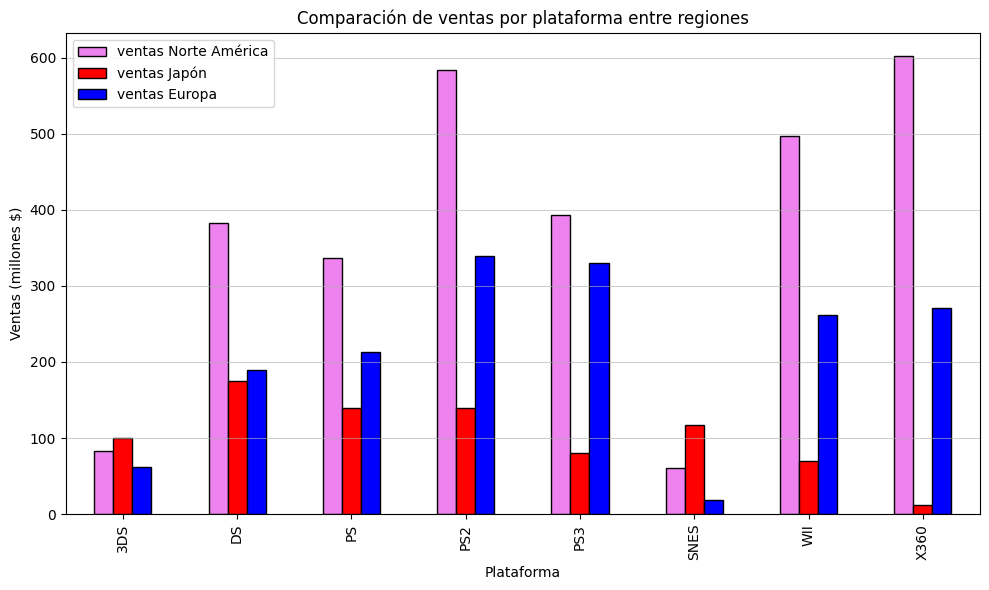

In [50]:
# Grafico la agrupación
df_top_platforms_region.plot(
    kind="bar",
    figsize=(10,6),
    title="Comparación de ventas por plataforma entre regiones",
    color=["violet", "red", "blue"],
    edgecolor="black"
)
plt.legend(["ventas Norte América", "ventas Japón", "ventas Europa"])
plt.xlabel("Plataforma")
plt.ylabel("Ventas (millones $)")
plt.grid(axis="y", alpha=0.6)
plt.tight_layout()
plt.show()


- Se puede observar que el tamaño del mercado japonés es bastante más pequeño que el de Europa y Norte América.
- El mercado con mayor volumen de ventas es el norteamericano, además X360, PS2 y Wii son superventas!
- X360 no ha conseguido tener relevancia en el mercado japonés.

## Perfil de ventas de géneros populares por región.

In [51]:
# Creo una función para obtener los 5 géneros con más ventas por región
def top_genres_region(df, sales_region):
    resultado = df
    resultado = resultado.groupby('genre')[sales_region].sum()
    resultado = resultado.sort_values(ascending = False)
    resultado = resultado.head(5).reset_index()
    return resultado

In [52]:
# Aplico la función y creo data frame parciales
top_NA_genres = top_genres_region(df,'na_sales')
top_EU_genres = top_genres_region(df,'eu_sales')
top_JP_genres = top_genres_region(df,'jp_sales')

In [53]:
# Creo un data frame que contiene las ventas por género combinadas
comparacion_generos_regiones = pd.DataFrame({
    "NA": top_NA_genres.set_index("genre")["na_sales"],
    "EU": top_EU_genres.set_index("genre")["eu_sales"],
    "JP": top_JP_genres.set_index("genre")["jp_sales"]
})
comparacion_generos_regiones

,NA,EU,JP
genre,,,
Action,879.01,519.13,161.43
Misc,407.27,212.74,108.11
Platform,445.50,NaN,130.83
Racing,NaN,236.51,NaN
Role-Playing,NaN,NaN,355.41
Shooter,592.24,317.34,NaN
Sports,684.43,376.79,135.54


Al unir los datos se observa que hay valores nulos, en las celdas que sigue lo soluciono.

In [54]:
# Obtengo una lista con las plataformas populares en todas las regiones
lista_genre = comparacion_generos_regiones.index
# Obtengo un df que contiene los juegos populares
df_top_genre_region = df[df['genre'].isin(lista_genre)]
# Agrupo por género y ventas por regiones
df_top_genre_region = df_top_genre_region.groupby('genre')[lista_region_sales].sum()
df_top_genre_region

,na_sales,jp_sales,eu_sales
genre,,,
Action,879.01,161.43,519.13
Misc,407.27,108.11,212.74
Platform,445.50,130.83,200.35
Racing,359.35,56.71,236.51
Role-Playing,330.81,355.41,188.71
Shooter,592.24,38.76,317.34
Sports,684.43,135.54,376.79


Ok sin valores nulos.

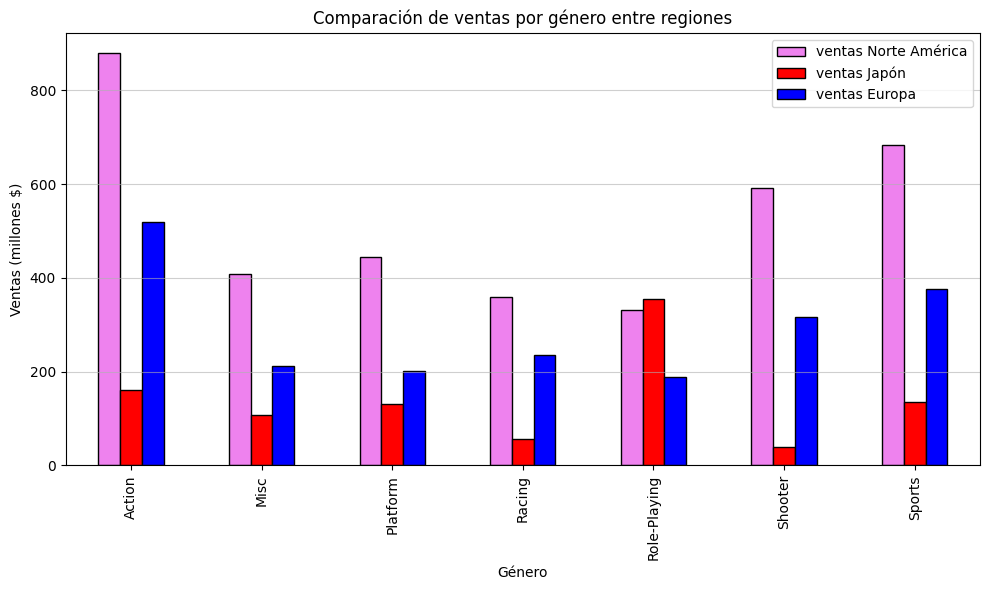

In [55]:
# Grafico la agrupación
df_top_genre_region.plot(
    kind="bar",
    figsize=(10,6),
    title="Comparación de ventas por género entre regiones",
    color=["violet", "red", "blue"],
    edgecolor="black"
)
plt.legend(["ventas Norte América", "ventas Japón", "ventas Europa"])
plt.xlabel("Género")
plt.ylabel("Ventas (millones $)")
plt.grid(axis="y", alpha=0.6)
plt.tight_layout()
plt.show()


- Los géneros más populares para NA son: action, sports y shooter.
- Los géneros más populares para JP son: role-playing, action y platform.
- Los géneros más populares para EU son: action, sports y shooter.
- Se puede destacar que el género favorito de Japón es Role-Playing!

## Venta por regiones según el ESBR (sistema de calificación por edades)

In [56]:
# Creo un df alternativo al original para evitar problemas
df_ESRB = df.copy()
# Para los valores ausentes en rating los sustituyo por "Sin ESRB"
df_ESRB['rating'].fillna('Sin ESRB', inplace = True)

In [57]:
# Agrupo por ventas totales según el rating
df_ESRB_sales = df_ESRB.groupby('rating')[lista_region_sales].sum()

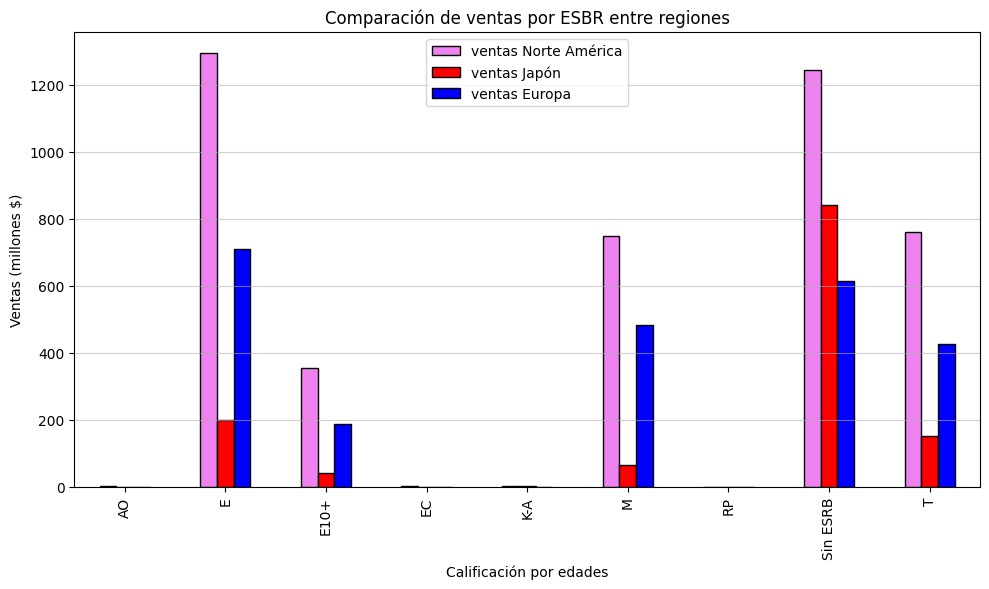

In [58]:
# Grafico
df_ESRB_sales.plot(
    kind="bar",
    figsize=(10,6),
    title="Comparación de ventas por ESBR entre regiones",
    color=["violet", "red", "blue"],
    edgecolor="black"
)
plt.legend(["ventas Norte América", "ventas Japón", "ventas Europa"])
plt.xlabel("Calificación por edades")
plt.ylabel("Ventas (millones $)")
plt.grid(axis="y", alpha=0.6)
plt.tight_layout()
plt.show()

- Se puede apreciar que el tamaño del mercado japones es más pequeño que el de norte américa y europa.
- Las ventas se concentran en calificaciones de E (Everyone) apto para todos los publicos.
- Destacan las calificaciones: recomendo a partir de 10 años (E10+), a partir de 17 años (M : mature) y jovenes a partir de 13 años (T : teen).
- La causas de que haya tantos títulos sin calificación ESRB puede ser variada, gran parte es porque el ESRB se estableció en 1994.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Javier has logrado identificar claramente las diferencias entre América del Norte, Europa y Japón, no solo en términos de plataformas y géneros predominantes, sino también en la influencia de las clasificaciones ESRB, lo que refleja tu capacidad para conectar datos con tendencias culturales y de comportamiento. 

</div>

## 5. Prueba las siguientes hipótesis:

- `h0`(hipótesis nula) = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
  
- `h1`(hipótesis alternativa) = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

In [59]:
# Filtro los datos y elimino valores ausentes en user_score
calificaciones_user_xboxone = df[df['platform'] == 'XONE']['user_score'].dropna()
calificaciones_user_PC = df[df['platform'] == 'PC']['user_score'].dropna()

In [60]:
print('Media de calificaciones de score para Xbox One:',round(calificaciones_user_xboxone.mean(),2))
print('Media de calificaciones de score para PC:',round(calificaciones_user_PC.mean(),2))

Media de calificaciones de score para Xbox One: 6.52
Media de calificaciones de score para PC: 7.06


Por la diferencia entre el valor de las medias se puede intuir que se rechazará la hipótesis nula.

In [61]:
var_compare = True
# Verifico que las varianzas entre distribuciones son diferentes.
if np.var(calificaciones_user_xboxone) != np.var(calificaciones_user_PC):
    var_compare = False
Else: var_compare = True

# Asigno el nivel de significancia en 5%
alpha = 0.05
# Aplico la  prueba t de dos muestras independientes para obtener .pvalue
results = st.ttest_ind(calificaciones_user_xboxone,calificaciones_user_PC,equal_var= var_compare)

print('valor p:', results.pvalue)
# Si pvalue es menor para una significancia del 5% las muestras se rechaza la hipotesis nula
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 4.935072360183574e-06
Rechazamos la hipótesis nula


Los datos estadísticos son consistentes con `h1`(hipótesis alternativa) = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes (para una significancia del 5%).

- `h0`(hipótesis nula) = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
  
- `h1`(hipótesis alternativa) = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales.

In [62]:
# Filtro los datos y elimino valores ausentes
calificaciones_user_action = df[df['genre'] == 'Action']['user_score'].dropna()
calificaciones_user_sports = df[df['genre'] == 'Sports']['user_score'].dropna()

In [63]:
print('Media de calificaciones de score para el género deporte:',round(calificaciones_user_sports.mean(),2))
print('Media de calificaciones de score para el género acción:',round(calificaciones_user_action.mean(),2))

Media de calificaciones de score para el género deporte: 6.96
Media de calificaciones de score para el género acción: 7.05


El valor de las medias es similar se puede intuir que se rechazará la hipótesis nula.

In [64]:
var_compare = True
# Verifico que las varianzas entre distribuciones son diferentes
if np.var(calificaciones_user_action) != np.var(calificaciones_user_sports):
    var_compare = False
Else: var_compare = True

# Asigno el nivel de significancia en 5%
alpha = 0.05
# Aplico la  prueba t de dos muestras independientes para obtener .pvalue
results = st.ttest_ind(calificaciones_user_action,calificaciones_user_sports,equal_var= var_compare)

print('valor p:', results.pvalue)
# Si pvalue es menor para una significancia del 5% las muestras se rechaza la hipotesis nula
if results.pvalue > alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 0.11483818791499333
Rechazamos la hipótesis nula


Los datos estadísticos son consistentes con `h1`(hipótesis alternativa) = Las calificaciones promedio de los usuarios para los géneros Acción y Deportes son iguales (para una significancia del 5%).

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Javier aplicaste correctamente las prueba de hipótesis comparando las distribuciones dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto servirá para tener una interpretación más precisa de los resultados además garantizará que la prueba t sea estadísticamente válida.

</div>
</div>

## 6. Conclusión general

El mercado de los videojuegos ha cambiado mucho con los años. Pasó de crecer sin parar a estabilizarse, con unas pocas consolas dominando las ventas. PlayStation 2, PlayStation 3 y Xbox 360 fueron las más exitosas, y Norteamérica es la región donde más se compra, seguida de Europa. Los jugadores prefieren sobre todo juegos de acción, deportes y disparos, mientras que Japón destaca por su gusto por los juegos de rol. En conjunto, los datos muestran un sector muy competitivo, donde las modas, las generaciones de consolas y las diferencias entre regiones influyen directamente en qué plataformas y juegos triunfan.

## Distribución de ventas por año por plataforma (interactiva)

Para facilitar la vista de la distribución de las ventas por plataforma he creado una función para gráficar cada una `graf_ventas_año_plataforma(plataforma,df)`

In [65]:
# Creo un diccionario para poder mostrar el nombre completo en el titulo de la grafica
dic_plataformas = {
    '2600': 'Atari 2600',
    '3DO': 'Panasonic 3DO',
    '3DS': 'Nintendo 3DS',
    'DC': 'Sega Dreamcast',
    'DS': 'Nintendo DS',
    'GB': 'Game Boy',
    'GBA': 'Game Boy Advance',
    'GC': 'Nintendo GameCube',
    'GEN': 'Sega Genesis',
    'GG': 'Sega Game Gear',
    'N64': 'Nintendo 64',
    'NES': 'Nintendo Entertainment System',
    'NG': 'Neo Geo',
    'PC': 'PC',
    'PCFX': 'NEC PC-FX',
    'PS': 'PlayStation',
    'PS2': 'PlayStation 2',
    'PS3': 'PlayStation 3',
    'PS4': 'PlayStation 4',
    'PSP': 'PlayStation Portable',
    'PSV': 'PlayStation Vita',
    'SAT': 'Sega Saturn',
    'SCD': 'Sega CD',
    'SNES': 'Super Nintendo Entertainment System',
    'TG16': 'TurboGrafx-16 / PC Engine',
    'WII': 'Nintendo Wii',
    'WIIU': 'Nintendo Wii U',
    'WS': 'WonderSwan',
    'X360': 'Xbox 360',
    'XB': 'Xbox',
    'XONE': 'Xbox One'
}

In [66]:
lista_plataformas = df['platform'].unique()
lista_plataformas

array(['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG',
       'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP',
       'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WII', 'WIIU', 'WS', 'X360',
       'XB', 'XONE'], dtype=object)

In [67]:
# Creo esta tabla para mostrar las opciones a consultar
tabla_platforms = {
    'Acrónimo': lista_plataformas,
    'Plataforma': [
        'Atari 2600','Panasonic 3DO','Nintendo 3DS','Sega Dreamcast','Nintendo DS',
        'Game Boy','Game Boy Advance','Nintendo GameCube','Sega Genesis','Sega Game Gear',
        'Nintendo 64','Nintendo Entertainment System','Neo Geo','PC','NEC PC-FX',
        'PlayStation','PlayStation 2','PlayStation 3','PlayStation 4','PlayStation Portable',
        'PlayStation Vita','Sega Saturn','Sega CD','Super Nintendo Entertainment System',
        'TurboGrafx-16 / PC Engine','Nintendo Wii','Nintendo Wii U','WonderSwan',
        'Xbox 360','Xbox','Xbox One'
    ]
}

df_tabla_platforms = pd.DataFrame(tabla_platforms)

In [68]:
def graf_ventas_año_plataforma(plataforma,df):
    año_plataforma_ventas = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
    plt.figure(figsize=(12,6))
    sns.lineplot(
    data = año_plataforma_ventas[año_plataforma_ventas['platform'] == plataforma],
    x='year_of_release',
    y='total_sales',
    hue='platform'
    )

    plt.title(f'Distribución anual de ventas {dic_plataformas[plataforma]}')
    plt.xlabel('Año')
    plt.ylabel('Ventas totales (millones)')
    plt.grid(True)
    plt.show()


   Acrónimo                           Plataforma
0      2600                           Atari 2600
1       3DO                        Panasonic 3DO
2       3DS                         Nintendo 3DS
3        DC                       Sega Dreamcast
4        DS                          Nintendo DS
5        GB                             Game Boy
6       GBA                     Game Boy Advance
7        GC                    Nintendo GameCube
8       GEN                         Sega Genesis
9        GG                       Sega Game Gear
10      N64                          Nintendo 64
11      NES        Nintendo Entertainment System
12       NG                              Neo Geo
13       PC                                   PC
14     PCFX                            NEC PC-FX
15       PS                          PlayStation
16      PS2                        PlayStation 2
17      PS3                        PlayStation 3
18      PS4                        PlayStation 4
19      PSP         

Introduce el acrónimo de la plataforma:  pc


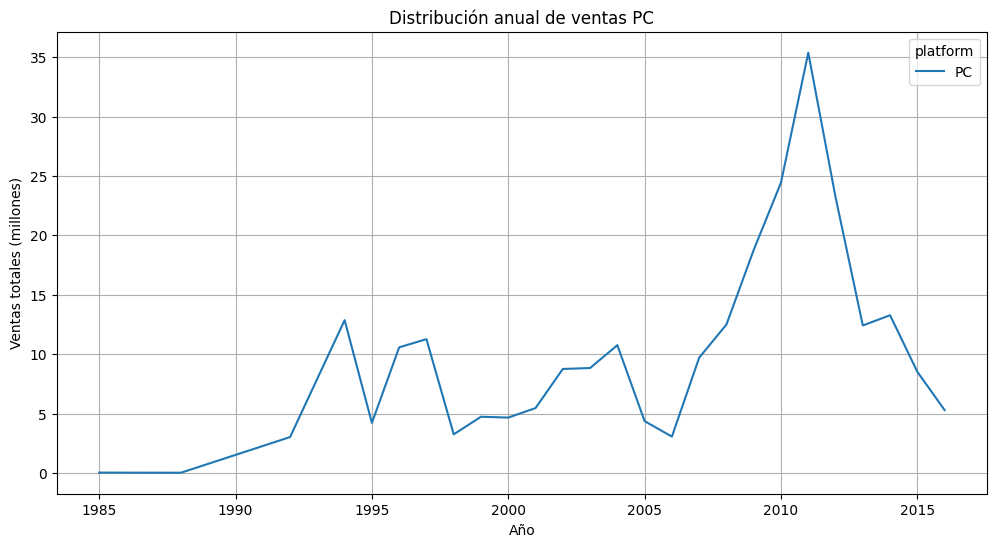

In [69]:
# Muestro las plataformas a consultar
print(df_tabla_platforms)
# Evito el tipado en minúsculas
plataforma = input("Introduce el acrónimo de la plataforma: ").upper()
graf_ventas_año_plataforma(plataforma,df)

## Distribución de ventas por de títulos por plataforma (interactiva)

- Para facilitar la vista de la distribución de las ventas de titulos por plataforma he creado una función para gráficar cada una `hist_ventas_plataforma(plataforma, df):`

La gráfica refleja un histograma que representa la frecuencia de ventas para un rango determinado de 

In [70]:
def hist_ventas_plataforma(plataforma, df):
    filtro = df[df['platform'] == plataforma].copy()
    plt.figure(figsize=(10, 5))
    plt.hist(filtro['total_sales'], bins=100, edgecolor='black')
    plt.xlabel('Millones de $')
    plt.ylabel('Frecuencia de títulos')
    plt.title(f'Distribución de ventas (títulos vendidos por intervalo) {dic_plataformas[plataforma]}')
    plt.grid(True, axis='y')
    plt.show()

   Acrónimo                           Plataforma
0      2600                           Atari 2600
1       3DO                        Panasonic 3DO
2       3DS                         Nintendo 3DS
3        DC                       Sega Dreamcast
4        DS                          Nintendo DS
5        GB                             Game Boy
6       GBA                     Game Boy Advance
7        GC                    Nintendo GameCube
8       GEN                         Sega Genesis
9        GG                       Sega Game Gear
10      N64                          Nintendo 64
11      NES        Nintendo Entertainment System
12       NG                              Neo Geo
13       PC                                   PC
14     PCFX                            NEC PC-FX
15       PS                          PlayStation
16      PS2                        PlayStation 2
17      PS3                        PlayStation 3
18      PS4                        PlayStation 4
19      PSP         

Introduce el acrónimo de la plataforma:  ps


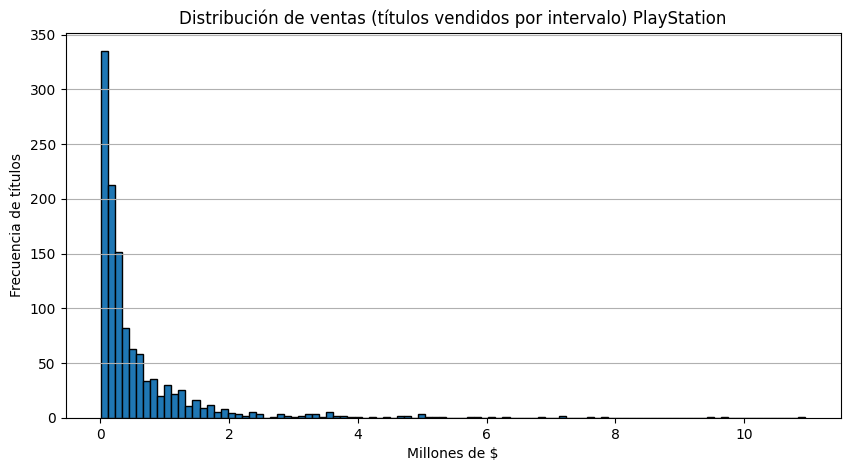

In [71]:
# Muestro las plataformas a consultar
print(df_tabla_platforms)
# Evito el tipado en minúsculas
plataforma = input("Introduce el acrónimo de la plataforma: ").upper()
hist_ventas_plataforma(plataforma, df)